## P3.b — Índice IVF (listas invertidas)

- **Entrada:** `data/p3/vectores/`
- **Salida:** `data/p3/centroides/` (los `NLIST` centroides) y `data/p3/listas/` (a qué lista va cada proceso y qué `NPROBE` listas se revisan al consultarlo)
- **IVF:** KMeans parte el espacio en `NLIST` regiones; cada vector se guarda en la lista de su centroide más cercano. Al consultar, sólo se recorren las `NPROBE` listas más cercanas a la consulta, no todo el índice
- **HNSW** (grafo jerárquico de vecinos) no tiene implementación distribuida en Spark ML; aquí se usa IVF, que sí se expresa con KMeans + joins

### Imports

In [1]:
import os, socket, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes y funciones compartidas (`03_P3/p3_funciones.ipynb`)

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
ruta_funciones = str(proyecto / "03_P3" / "p3_funciones.ipynb")
%run $ruta_funciones

final_dir      = proyecto / "data" / "final"
vectores_dir   = proyecto / "data" / "p3" / "vectores"
centroides_dir = proyecto / "data" / "p3" / "centroides"
listas_dir     = proyecto / "data" / "p3" / "listas"
vecinos_dir    = proyecto / "data" / "p3" / "vecinos"

/opt/conda/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("p3_b_indice_ivf")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga

In [5]:
assert vectores_dir.exists(), f"No se encuentra {vectores_dir}; corre a_vectores_tfidf.ipynb"
vectores = spark.read.parquet(str(vectores_dir)).select("ocid", "categoria", "vec", "idx", "val").cache()
N = vectores.count()
print(f"Vectores: {N:,} | NLIST = {NLIST} (≈ {N / NLIST:,.0f} vectores por lista) | NPROBE = {NPROBE}")

Vectores: 231,171 | NLIST = 300 (≈ 771 vectores por lista) | NPROBE = 2


### 2. Cuantizador grueso: KMeans

In [6]:
t0 = time.time()
km, centroides = entrenar_centroides(vectores)
print(f"KMeans k={NLIST}: {time.time() - t0:,.0f} s | centroides {centroides.shape}")

spark.createDataFrame([(i, c.tolist()) for i, c in enumerate(centroides)], "lista int, centroide array<double>") \
     .write.mode("overwrite").parquet(str(centroides_dir))

KMeans k=300: 80 s | centroides (300, 4096)


### 3. Asignación a listas

- `listas_probe[0]` = lista donde se indexa el proceso; `listas_probe` completo = listas que se revisan cuando el proceso es consulta

In [7]:
asignar = asignar_listas_udf(sc.broadcast(centroides))
listas = (vectores.withColumn("listas_probe", asignar("idx", "val"))
                  .withColumn("lista", F.col("listas_probe")[0])
                  .select("ocid", "categoria", "lista", "listas_probe"))
listas.write.mode("overwrite").parquet(str(listas_dir))
listas = spark.read.parquet(str(listas_dir)).cache()

### 4. Checkpoint: listas

- Toda fila tiene lista, la asignación coincide con `KMeansModel.predict`, y la distribución de tamaños

Listas asignadas: 231,171 de 231,171 | coinciden con predict de KMeans: 231,171 (100.0%)
Tamaño de lista: min 1 | mediana 504 | max 26,608 | listas vacías: 0
+---------+-------------+--------+
|categoria|listas_usadas|vectores|
+---------+-------------+--------+
| SERVICES|          281|  100050|
|    GOODS|          279|  104002|
|    WORKS|          204|   27119|
+---------+-------------+--------+



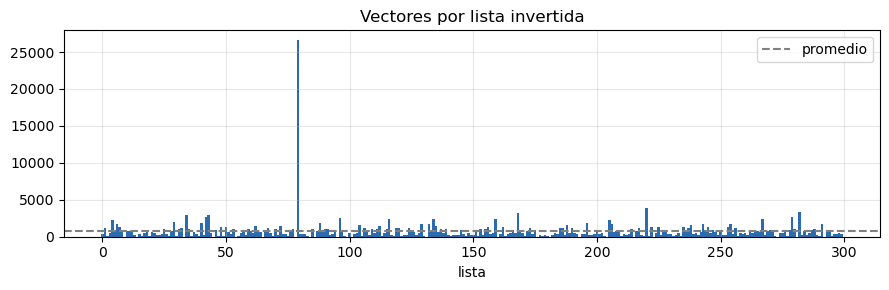

In [8]:
n_l = listas.count()
coinciden = (km.transform(vectores).select("ocid", "lista").join(listas.select("ocid", F.col("lista").alias("lista_udf")), "ocid")
               .where("lista = lista_udf").count())
print(f"Listas asignadas: {n_l:,} de {N:,} | coinciden con predict de KMeans: {coinciden:,} ({coinciden / N:.1%})")
assert n_l == N and listas.where(F.size("listas_probe") != NPROBE).count() == 0

tam = listas.groupBy("lista").count().orderBy("lista").toPandas()
print(f"Tamaño de lista: min {tam['count'].min():,} | mediana {tam['count'].median():,.0f} | max {tam['count'].max():,} | listas vacías: {NLIST - len(tam)}")
listas.groupBy("categoria").agg(F.countDistinct("lista").alias("listas_usadas"), F.count("*").alias("vectores")).show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(tam["lista"], tam["count"], width=1, color="#2b6cb0"); ax.axhline(N / NLIST, color="gray", ls="--", label="promedio")
ax.set_title("Vectores por lista invertida"); ax.set_xlabel("lista"); ax.legend(); plt.tight_layout(); plt.show()

- Listas muy desiguales = algunas consultas revisan muchos más vectores que otras. Siguiente: `c_busqueda_ann.ipynb`

### 5. Cierre

In [9]:
spark.stop()